---
title: A spatial GEV — location as a Gaussian process
subtitle: Pooling that respects geography, fit fast with a Laplace approximation
short_title: Spatial GP location
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - Gaussian process
  - spatial pooling
  - Laplace approximation
  - Matérn kernel
  - nugget
  - return levels
abstract: |
  The hierarchical model pooled the stations, but blindly — it pulled every
  station toward one global mean regardless of where it sits. Here we make the
  pooling spatial: the GEV location becomes μ(s) = μ₀ + f(s) + εₛ, with f a
  Gaussian-process field over (lon, lat) so nearby stations inform each other,
  plus a per-station nugget that absorbs local, sub-grid structure. We fit it
  first with a fast Laplace approximation — a Gaussian centred at the posterior
  mode — and then confirm that approximation against full NUTS. The result is a
  continuous location surface with calibrated uncertainty everywhere, including
  ungauged ground, and 100-year levels far tighter than the independent fits.
---

# A spatial GEV: location as a Gaussian process

Notebook 05 pooled the stations with a hierarchical prior and cut the tail
uncertainty sharply — but the pooling was **spatially blind**. Its prior,
$\mu_s \sim \mathcal N(\mu_0, \tau_\mu^2)$, is *exchangeable*: it pulls a station
in the cool northern interior and a station on the warm Mediterranean coast
toward the **same** global mean $\mu_0$. Geography never enters.

This notebook fixes that. We let the GEV **location** be a smooth spatial
function plus local structure,

$$
y_{s,t} \sim \mathrm{GEV}\big(\mu(s),\ \sigma,\ \xi\big), \qquad
\mu(s) = \mu_0 + f(s) + \varepsilon_s,
$$

with the pieces

* $f(s) \sim \mathcal{GP}\big(0,\ k(\,\cdot,\cdot\,)\big)$ — a **Gaussian-process**
  field over $(\text{lon}, \text{lat})$. A GP is a prior over smooth functions:
  the kernel $k(s, s')$ says how strongly two locations are correlated as a
  function of the distance between them, so values at nearby stations are tied
  together and the field interpolates smoothly between them. We use a
  **Matérn-3/2** kernel with a fixed *regional* lengthscale (more on that
  choice below).
* $\varepsilon_s \sim \mathcal N(0, \tau_\varepsilon^2)$ — a per-station
  **nugget**. Spanish station temperatures depend strongly on **elevation**, which
  $(\text{lon}, \text{lat})$ alone cannot see; the nugget absorbs that local
  variation so the GP field is free to capture the genuinely *regional* trend
  rather than being forced to wiggle through every station.
* $\sigma, \xi$ are **global** — a deliberate first-model simplification.
  Notebook 05 already showed the tail $\xi$ pools to a single value anyway; the
  capstones later let $\sigma(s), \xi(s)$ vary in space too.

**On inference.** A latent GP field over many stations is a big correlated object,
so we **start with a Laplace approximation**: optimise to the posterior mode (the
MAP), then approximate the posterior by the Gaussian whose covariance is the
curvature (inverse Hessian) at that mode. It costs a single optimisation —
seconds — and is exact when the posterior is roughly Gaussian. We lead with it,
read off the maps, and *then* check it honestly against a full NUTS run.

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.infer.initialization import init_to_median

from pyrox_gp import GPPrior, Matern, gp_sample
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data
from spatial_extremes.data import IBERIA_BBOX
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)                       # (S, T) — NaN where a year is missing
mask = ~jnp.isnan(Y)                          # observed-entry mask for the likelihood
S, T = Y.shape
lon, lat = stations[:, 0], stations[:, 1]
Xs = jnp.asarray(stations)
Xm, Xsd = Xs.mean(0), Xs.std(0)
Xn = (Xs - Xm) / Xsd                          # standardised coords for the kernel
ybar = jnp.asarray(np.nanmean(maxima, axis=1))   # per-station mean (gap fill / prior)
Y_MEAN = float(np.nanmean(maxima))
LENGTHSCALE = 0.8                             # fixed regional lengthscale (std units)
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")
print(f"coverage: {int(np.asarray(mask.sum(1)).min())}-"
      f"{int(np.asarray(mask.sum(1)).max())} yrs/station, "
      f"{100 * float(mask.mean()):.0f}% of the {S}×{T} grid observed")

/home/azureuser/localfiles/research/research_notebook/.claude/worktrees/spatial-extremes-refresh/projects/spatial_extremes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source: SYNTHETIC | stations 40 | years 1950-2024 (75)
coverage: 75-75 yrs/station, 100% of the 40×75 grid observed


## The model

The GP field is sampled in **whitened** coordinates ($f = L\,u$ with
$u \sim \mathcal N(0, I)$ and $L$ the Cholesky factor of the kernel matrix), which
turns the strongly-correlated field into independent standard-normal draws — far
easier for any sampler or optimiser. We centre $f$ to remove its additive
degeneracy with $\mu_0$, keep the $\log\sigma$ / bounded-$\xi$ reparameterisation
from notebook 04, and give the nugget a non-centred form $\varepsilon_s =
\tau_\varepsilon z_s$. The records are ragged (we keep stations with $\ge 20$
years), so the likelihood **masks** missing station-years — only observed
entries enter the `numpyro.factor`.

In [4]:
def spatial_model(Xn, Y=None):
    # smooth regional field f(s): Matérn-3/2, fixed lengthscale, learned amplitude
    k = Matern(nu=1.5, init_lengthscale=LENGTHSCALE)
    k.set_prior("variance", ndist.LogNormal(jnp.log(4.0), 0.5))
    f = gp_sample("f", GPPrior(kernel=k, X=Xn), whitened=True)
    f = f - jnp.mean(f)                                   # fix f vs mu0 degeneracy

    mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
    tau_eps = numpyro.sample("tau_eps", ndist.HalfNormal(2.0))     # nugget scale
    log_sigma = numpyro.sample("log_sigma", ndist.Normal(jnp.log(2.0), 0.4))
    xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))
    with numpyro.plate("stations", S):
        z = numpyro.sample("z", ndist.Normal(0.0, 1.0))           # non-centred nugget

    sigma = numpyro.deterministic("sigma", jnp.exp(log_sigma))
    xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
    f_smooth = numpyro.deterministic("f_smooth", f)               # regional component
    mu_field = numpyro.deterministic("mu_field", mu0 + f + tau_eps * z)
    if Y is not None:
        # masked likelihood: only observed (non-NaN) station-years contribute
        yf = jnp.where(mask, Y, ybar[:, None])
        lp = GEV(loc=mu_field[:, None], scale=sigma,
                 concentration=xi).log_prob(yf)
        numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())

## Fit, fast — the Laplace approximation

`AutoLaplaceApproximation` optimises the model to its MAP and reads the Gaussian
posterior off the curvature there. We drive the optimisation with Adam (guarding
against the occasional out-of-support GEV gradient), and the ELBO loss curve
below should settle to a flat plateau — the sign it has found the mode.

Laplace fit in 45.5s · final ELBO loss 5629.6


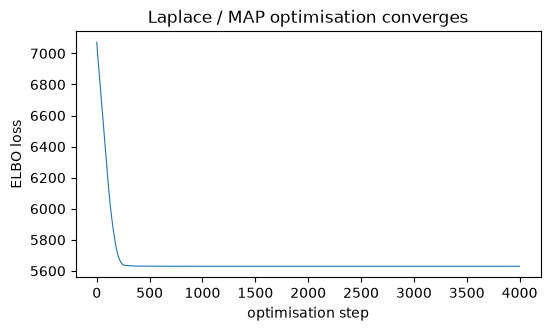

In [5]:
guide = AutoLaplaceApproximation(spatial_model, init_loc_fn=init_to_median)
opt = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(spatial_model, guide, opt, Trace_ELBO())
t0 = time.time()
res = svi.run(jr.PRNGKey(0), 4000, Xn, Y, progress_bar=False)
losses = np.asarray(res.losses)
finite = losses[np.isfinite(losses)]
print(f"Laplace fit in {time.time() - t0:.1f}s · final ELBO loss "
      f"{float(finite[-1]):.1f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.where(np.isfinite(losses), losses, np.nan), lw=0.8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("ELBO loss")
ax.set_title("Laplace / MAP optimisation converges")
plt.show()

## Read off the posterior

We draw from the Laplace Gaussian with `guide.sample_posterior`, then push those
draws back through the model with `Predictive` to get posterior samples of every
derived quantity — the location field $\mu(s)$, the smooth component $f(s)$, and
the global $\sigma, \xi$.

In [6]:
lap = guide.sample_posterior(jr.PRNGKey(1), res.params, sample_shape=(600,))
pred = Predictive(spatial_model, posterior_samples=lap,
                  return_sites=["mu_field", "f_smooth", "sigma", "xi"])
draws = pred(jr.PRNGKey(2), Xn)

mu_field = np.asarray(draws["mu_field"])      # (n, S)
f_smooth = np.asarray(draws["f_smooth"])      # (n, S)
xi = np.asarray(draws["xi"])                  # (n,)
sigma = np.asarray(draws["sigma"])            # (n,)
mu0_med = float(np.median(np.asarray(lap["mu0"])))
var_med = float(np.median(np.asarray(lap["Matern.variance"])))

print(f"global tail   ξ = {xi.mean():+.3f} ± {xi.std():.3f}")
print(f"global scale  σ = {sigma.mean():.2f} ± {sigma.std():.2f} °C")
print(f"GP amplitude  √var = {np.sqrt(var_med):.2f} °C, fixed lengthscale = "
      f"{LENGTHSCALE} (≈ {LENGTHSCALE * float(Xsd[0]):.1f}° lon)")
print(f"smooth field vs latitude: corr = "
      f"{np.corrcoef(f_smooth.mean(0), lat)[0, 1]:+.2f}")

global tail   ξ = -0.157 ± 0.010
global scale  σ = 1.44 ± 0.02 °C
GP amplitude  √var = 2.20 °C, fixed lengthscale = 0.8 (≈ 3.2° lon)
smooth field vs latitude: corr = +0.43


## What the GP extracts: a regional field

The location splits into a **smooth regional field** $f(s)$ — the part the GP can
explain from position alone — and the per-station remainder. The smooth field
tracks the north–south temperature gradient (its correlation with latitude is
printed above): the GP has discovered the large-scale geography that the
exchangeable hierarchical prior could not represent.

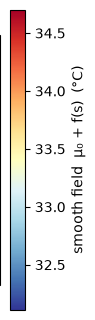

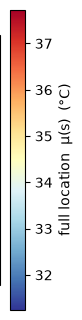

In [7]:
for vals, label, cmap in [
    (mu0_med + f_smooth.mean(0), "smooth field  μ₀ + f(s)  (°C)", "RdYlBu_r"),
    (mu_field.mean(0), "full location  μ(s)  (°C)", "RdYlBu_r"),
]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Spatial GEV · {label}")
    plt.show()

## The GP's superpower: a continuous surface with honest uncertainty

Neither the no-pooling nor the hierarchical model can say anything about a
location **without a station**. A GP can: conditioning the fitted field on the
stations gives a posterior over $f$ at *every* point on a grid — a continuous map,
and an uncertainty that is small near stations and grows into the gaps. We
interpolate the posterior-mean field onto a 60×60 grid over Iberia.

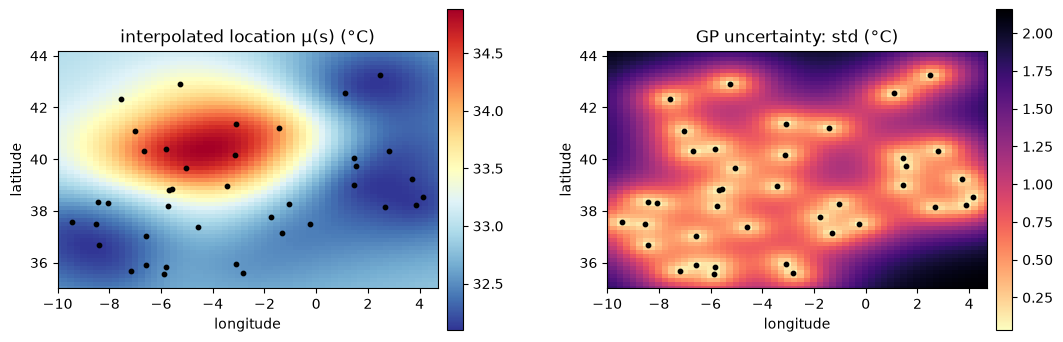

In [8]:
lon_min, lon_max, lat_min, lat_max = IBERIA_BBOX
glon = np.linspace(lon_min, lon_max, 60)
glat = np.linspace(lat_min, lat_max, 60)
GX, GY = np.meshgrid(glon, glat)
gridn = (jnp.asarray(np.stack([GX.ravel(), GY.ravel()], 1)) - Xm) / Xsd

k = Matern(nu=1.5, init_variance=var_med, init_lengthscale=LENGTHSCALE)
prior = GPPrior(kernel=k, X=Xn)
with numpyro.handlers.seed(rng_seed=0):
    cond = prior.condition(jnp.asarray(f_smooth.mean(0)), jnp.array(1e-3))
    gmean, gvar = cond.predict(gridn)
mu_grid = (np.asarray(gmean) + mu0_med).reshape(GX.shape)
std_grid = np.sqrt(np.asarray(gvar)).reshape(GX.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, field, title, cmap in [
    (axes[0], mu_grid, "interpolated location μ(s) (°C)", "RdYlBu_r"),
    (axes[1], std_grid, "GP uncertainty: std (°C)", "magma_r"),
]:
    pc = ax.pcolormesh(GX, GY, field, cmap=cmap, shading="auto")
    ax.scatter(lon, lat, s=10, c="k", zorder=3)
    ax.set_xlim(lon_min, lon_max); ax.set_ylim(lat_min, lat_max)
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    fig.colorbar(pc, ax=ax, shrink=0.8, pad=0.02)
plt.show()

## The payoff: 100-year return levels

The pooled, spatially-aware fit gives the 100-year level at every station with
**tight** credible intervals — the location borrows strength from neighbours and
the tail is shared. We print the average 95%-interval width below; for context,
it was ≈ 7.8 °C with no pooling and ≈ 2.7 °C under the hierarchical model. (These
are the Laplace intervals; the next section checks their *width* against NUTS,
where there turns out to be a catch.)

z100 median range : 35.9 -> 42.4 °C
z100 95% CI width : 3.3 °C avg (max 3.9)


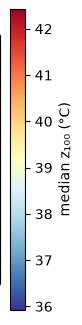

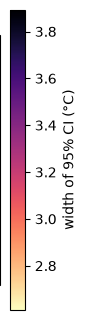

In [9]:
RL = np.asarray(gev_return_level(
    100.0, jnp.asarray(mu_field), jnp.asarray(sigma)[:, None],
    jnp.asarray(xi)[:, None]))                # (n, S)
rl_med = np.median(RL, 0)
rl_ciw = np.quantile(RL, 0.975, 0) - np.quantile(RL, 0.025, 0)
print(f"z100 median range : {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width : {rl_ciw.mean():.1f} °C avg (max {rl_ciw.max():.1f})")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Spatial GEV 100-year return level · {label}")
    plt.show()

## Takeaway

Making the pooling **spatial** was the right last move. The GP location field
recovers the regional geography the exchangeable hierarchy ignored, gives a
**continuous** map with uncertainty that honestly grows away from stations, and
keeps the 100-year intervals tight — all from a **Laplace fit in a few seconds**.

One honest caveat travels with that speed: Laplace centres a Gaussian at the
posterior mode, so its **point estimates** (the station maps, the global $\xi$)
are trustworthy, but its calibrated **interval widths** are only as good as that
Gaussian. The non-Gaussian geometry of a latent GP field plus a smooth/nugget
ridge can make the mode-centred bands too wide or too narrow. The working rule:
**start fast with Laplace for the answer, and reach for full MCMC when the
calibrated uncertainty is the thing you are selling.**

Two further caveats, each a door to the capstones:

* We **fixed** the GP lengthscale to a regional scale. Left free, the data pull
  it much shorter — the location really does vary at fine, elevation-driven
  scales that $(\text{lon}, \text{lat})$ cannot see, which is exactly why the
  nugget earns its place. Adding **elevation as a covariate** is the natural fix.
* We kept $\sigma, \xi$ **global**. The capstones relax this — a spatial
  warming rate $\beta(s)$, then non-stationary $\sigma(s), \xi(s)$, then a copula
  for *joint* exceedances across stations.
